In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,calculate_relative_distance_goal_ts,ts_angle_to_target_port,ts_lateral_error_to_target_port
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [3]:

font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 20}

plt.rc( 'font',**font);

In [4]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
#min_angle(joint)
#zero_out_angle_target_port(joint)
#con_df = create_consective_df_new(joint)
#
#long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)
#
#long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

In [5]:
deveation(joint)

In [6]:
calculate_relative_distance_goal_ts(joint)

In [7]:
ts_angle_to_target_port(joint)

In [8]:
ts_lateral_error_to_target_port(joint)

In [41]:
len(joint.ts_distance_from_edge[0])

242

In [42]:
len(joint.ts_distance_from_target_port[0])

242

In [31]:
int(np.argwhere(joint.ts_distance_from_edge[0]>= -2).max())

159

In [40]:
deveation(joint)

In [9]:
long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
long,short,middle = create_df_by_type(joint)

In [7]:
joint.obstacle_ind

0        159.0
1        205.0
2        127.0
3        199.0
4         30.0
         ...  
14548     20.0
14549     19.0
14550     22.0
14551     25.0
14552     35.0
Name: obstacle_ind, Length: 14553, dtype: float64

In [30]:
joint.obstacle_ind[0]

159.0

In [23]:
len(joint.ts_distance_from_target_port[0])

83

In [50]:
joint.ts_distance_from_target_port


0        [45.64798095578064, 45.42046165378143, 45.0841...
1        [45.65586423862204, 45.449515997814906, 45.127...
2        [45.587991181501394, 45.29694989247456, 45.133...
3        [45.58630054196045, 45.6330334276153, 45.61951...
4        [45.78404014797813, 45.39276746902501, 45.0229...
                               ...                        
14548    [38.95512922992756, 38.57043029358221, 38.1824...
14549    [38.65376425544137, 38.18855666843102, 37.5273...
14550    [38.56842176367112, 37.46103324363763, 36.7326...
14551    [39.01995452445051, 38.92120087791973, 38.8441...
14552    [39.32628230789149, 38.96007642987277, 38.6782...
Name: ts_distance_from_target_port, Length: 14553, dtype: object

In [49]:
joint.goal_distance_from_target_port

0        [23.530622968328792, 23.127280477729958, 22.72...
1        [32.90202432518845, 32.251259289148194, 31.607...
2        [23.609037048823375, 22.931674988553475, 22.25...
3        [33.549871239982835, 32.72671678375859, 31.922...
4        [24.13765509837161, 23.20237861012553, 22.4524...
                               ...                        
14548    [30.433422323956783, 30.17695571256948, 29.845...
14549    [29.40558517066778, 28.918574986655273, 28.429...
14550    [30.92910551048061, 30.783989862368877, 30.542...
14551    [32.06373071675414, 31.48580564535126, 30.8138...
14552    [28.720369967116575, 28.337669811868178, 27.81...
Name: goal_distance_from_target_port, Length: 14553, dtype: object

In [10]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)
    

In [ ]:
ts_lateral_error_to_target_port

In [11]:
goal_port(long_nostart)

In [139]:
long_nostart.goal_lateral_error_to_target_port

8        [3.6050216160984014, 3.861027239236588, 4.1436...
12       [4.581950412151482, 4.705552787021045, 4.79516...
17       [3.578414633038829, 3.7735599341282295, 3.9453...
22       [3.5559877994374958, 3.9140978859457363, 4.268...
24       [2.985139954262756, 3.297317496898632, 3.37006...
                               ...                        
14500    [7.914194965281977, 7.732255543496054, 7.54386...
14515    [8.798872188277858, 8.514265700116725, 8.28985...
14523    [2.9587756708252613, 3.3927620258097093, 3.886...
14535    [6.677823316885885, 6.447472842426105, 6.24615...
14547    [6.920381615393421, 6.657718604476592, 6.36580...
Name: goal_lateral_error_to_target_port, Length: 5295, dtype: object

In [51]:
long_nostart.goal_distance_from_target_port

8        [20.536981549518085, 20.51853830041654, 20.361...
12       [21.62435839201537, 21.439806329653436, 21.290...
17       [22.46647368419632, 22.210636822954093, 21.974...
22       [22.618214864633845, 22.31787739918677, 21.981...
24       [21.231166203492574, 20.714307559480282, 19.84...
                               ...                        
14500    [22.16368338090542, 21.201342045875748, 20.297...
14515    [22.036195509382303, 21.150030428161966, 20.26...
14523    [20.41462377328392, 19.849732118528202, 19.546...
14535    [21.469570171671133, 20.612487916174807, 19.74...
14547    [19.005089157371852, 18.00419551802067, 17.015...
Name: goal_distance_from_target_port, Length: 5295, dtype: object

In [79]:
row[1]['obstacle_ind']

53.0

In [82]:
len(row[1]['ts_nose_x_cm'])

115

In [83]:
len(row[1]['ts_angle_to_target_port'])

115

In [60]:
task_df.goal_angle_to_target_port

8       143      [21.6663021793495, 20.918464518901523...
12      267      [26.32306050618494, 28.50482674336940...
17      139      [6.831243426234441, 3.178160637494679...
22      152      [32.328436419535535, 38.8693309409142...
24      75       [14.918792726698186, 14.9414981693673...
                              ...                        
8809    29       [40.880691394021795, 42.0754832161700...
8827    35       [12.404900908831369, 22.5906767394243...
8866    28       [113.16960347088224, 20.2191897437150...
8874    29       [40.880691394021795, 42.0754832161700...
8875    34       [23.764867168494167, 18.7291566014985...
Name: goal_angle_to_target_port, Length: 3278, dtype: object

In [ ]:
row[1]['ts_angle_to_target_port']

In [87]:
row[1]['ts_angle_to_target_port'][int(row[1]['obstacle_ind']):]

array([14.239005243339205, 16.549587825238806, 24.808054752991307,
       25.898387348251962, 25.796889590225476, 32.9595404008351,
       36.026208276051335, 37.227568501452524, 39.792241497291805,
       37.28211618050353, 38.08540453811856, 39.42925479587827,
       39.97476064782308, 45.15614913796039, 43.5264893780544,
       34.226010683214206, 28.90790053578346, 24.596268688001224,
       25.48553939064918, 27.718859594533306, 29.395760264874653,
       30.968234512637277, 34.43129527903421, 34.854927952006435,
       41.34259106954216, 47.40166070654576, 51.944417223455744,
       45.84249732542299, 50.132309885011054, 50.51440301460364,
       42.20549789648649, 32.930671322540896, 33.26647179969795,
       27.003329619413826, 22.474267646320694, 17.785546222476338,
       14.353991845105448, 13.262304885782667, 8.009225448653611,
       7.92743467566828, 6.738260987630524, 8.850549338959539,
       6.617956136951679, 4.529997585139517, 5.1661586338747805,
       4.55416958003

In [86]:
len(y)

9

In [74]:
x

array([21.62903612, 21.08767598, 20.7758958 , 20.38587784, 19.93649623,
       19.75791178, 19.53980627, 19.54650761, 19.41216092, 19.37953675,
       19.35826605, 19.31924459, 19.23552645, 19.14063443, 18.99971166,
       18.53844623, 18.30595527, 17.91497872, 17.67266247, 17.39889762,
       16.93985925, 16.39979706, 16.05951841, 15.73514628, 15.21798963,
       14.90218118, 14.65564199, 14.24657331, 13.92289545, 13.39731498,
       12.81278957, 12.05599573, 11.47203147, 10.8811933 , 10.28962999,
        9.63574194,  8.84441456,  8.30893748,  7.54571406,  7.01456101,
        6.26919661,  5.68066263,  5.10392523,  4.57411652,  4.08988752,
        3.78301882,  3.3600736 ,  2.97490256,  2.53123513,  2.11972619,
        1.68379551,  1.23055616,  0.95208661,  0.84034096,  0.61333801,
        0.39825875,  0.36967003,  0.31127562,  0.31127562,  0.31127562,
        0.31127562,  0.31127562])

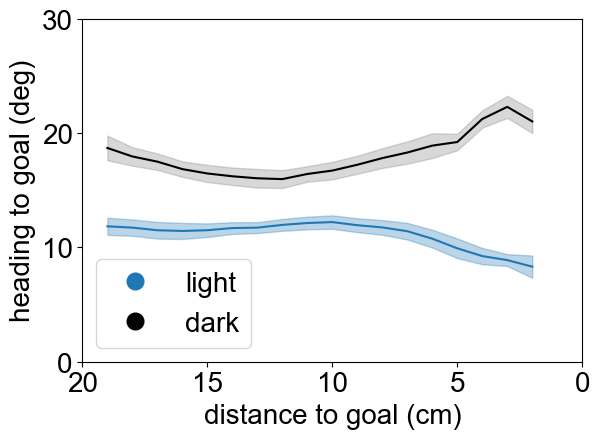

In [14]:
xnew =  np.arange(2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        y = row[1]['ts_angle_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            y = row[1]['ts_angle_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0]) 
ax.set_yticks([0,10,20,30])       
ax.set_ylabel('heading to goal (deg)')
ax.set_xlabel('distance to goal (cm)')
#ax.axvline(0, color='r', ls=':')
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/goal_port/heading_to_goal.pdf',dpi = 300)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN/goal_port/heading_to_goal.pdf',dpi = 300)

In [ ]:
sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))

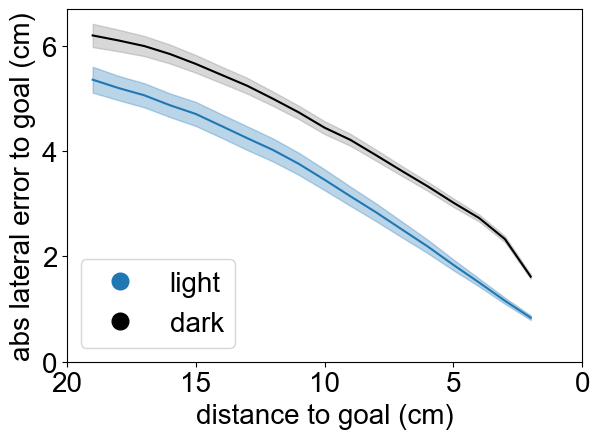

In [15]:
xnew =  np.arange(2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight')

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.date_index == 3]
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        y = row[1]['ts_lateral_error_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            y = row[1]['ts_lateral_error_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,2,4,6])    
ax.set_ylabel('abs lateral error to goal (cm)')
ax.set_xlabel('distance to goal (cm)')

   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/goal_port/lateral_error_to_goal.pdf',dpi = 300)

Text(0.5, 0.04, 'abs lateral error goal (cm)')

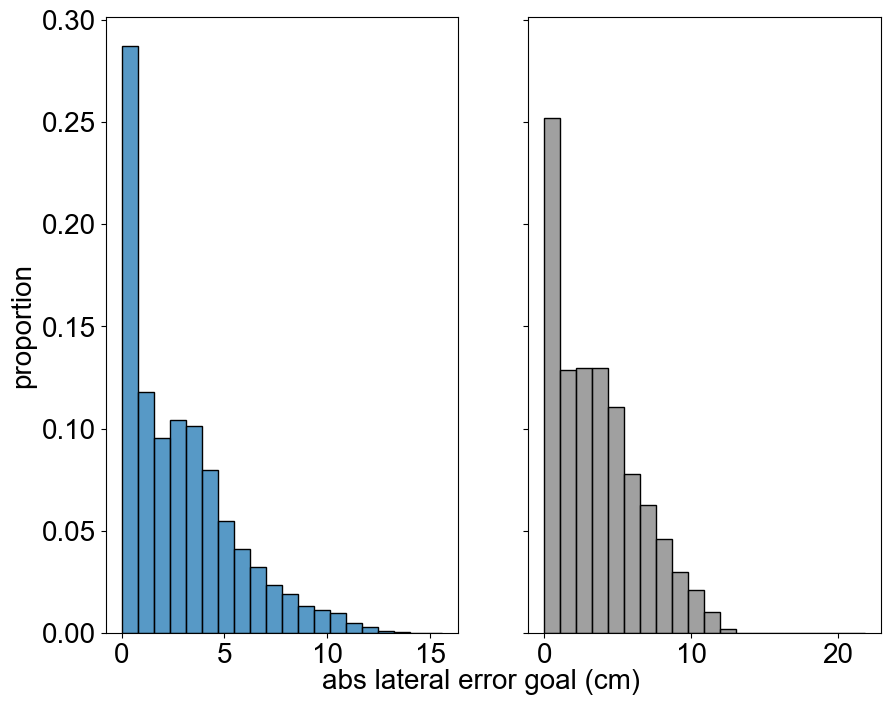

In [141]:
dark = long_nostart[long_nostart.task =='oadark']
light = long_nostart[long_nostart.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

light_dist = flatten_list_of_arrays(light.goal_lateral_error_to_target_port.to_list())

dark_dist = flatten_list_of_arrays(dark.goal_lateral_error_to_target_port.to_list())


sns.histplot(data = light_dist,ax =ax[0],stat='proportion',bins=20,color = 'tab:blue')
sns.histplot(data = dark_dist,ax =ax[1],stat='proportion',bins=20,color = 'grey')

#ax[0].set_xticks([0,5,10,15,20])

#ax[1].set_xticks([0,5,10,15,20])

ax[0].set_ylabel('proportion')
fig.text(0.5, 0.04, 'abs lateral error goal (cm)', ha='center')

In [110]:
row[1]['ts_lateral_error_to_target_port']

array([1.025699036507362, 1.2866163911225463, 1.3477933236852664,
       1.8020125059036438, 2.0763110288550912, 2.4143218094998424,
       2.5088256680437944, 2.6518992592364192, 3.1086177680541134,
       3.3674497791795375, 3.683740588852647, 3.8999169117516495,
       4.112395671224913, 4.646855579634963, 4.827380499962423,
       4.817434620038391, 4.951842850490582, 4.814482740474588,
       4.660025899430956, 4.431761783997597, 4.064347917279598,
       3.781162899752797, 3.4636609966349567, 3.1484450002524973,
       2.8011106000098778, 2.5511805114017783, 2.3158889684005857,
       2.1606093037851615, 2.187885905190061, 2.225463229184328,
       2.3368786834522624, 2.4484098472849816, 2.5659990496650167,
       2.737876608517677, 2.8040033391294585, 2.8466615986795425,
       2.8517399629116937, 3.0699553454745434, 3.1079775084623122,
       3.2993251300824973, 3.4311054677522783, 3.5225751643752474,
       3.709124696042423, 3.821519824625522, 3.8656900224887742,
       3.964

In [ ]:
        x = row[1]['ts_distance_from_target_port'][int(row[1]['obstacle_ind']):].astype(float)
            y = row[1]['ts_lateral_error_to_target_port'][int(row[1]['obstacle_ind']):].astype(float)

In [142]:
test = long.sample(10)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
    ax[1].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('heading to goal')
    ax[2].set_title('lateral error goal')
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( smooth(row.ts_distance_from_target_port[int(row.obstacle_ind):]),smooth(row.ts_lateral_error_to_target_port[int(row.obstacle_ind):]),color = 'tab:orange')
    ax[1].plot( smooth(row.ts_distance_from_target_port[int(row.obstacle_ind):]),smooth(row.ts_angle_to_target_port[int(row.obstacle_ind):]),color = 'tab:orange')

SyntaxError: unmatched ')' (3967780593.py, line 39)

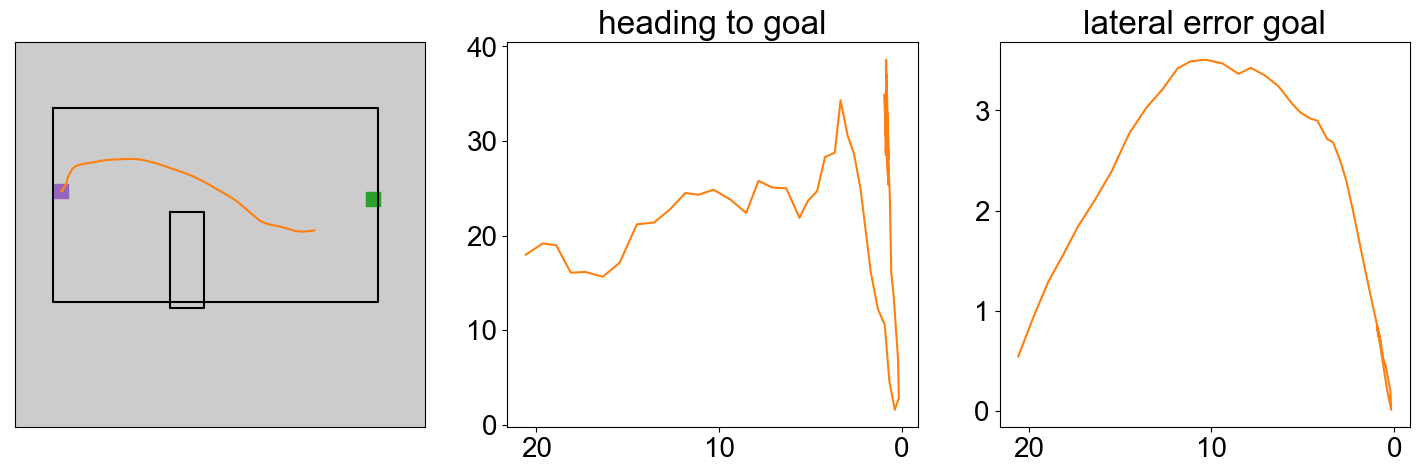

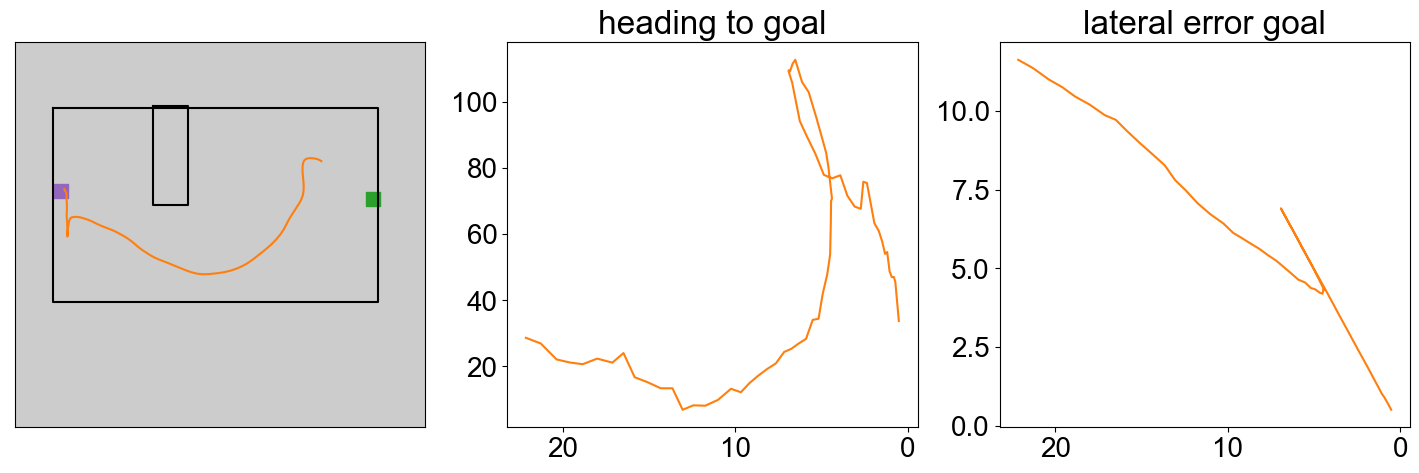

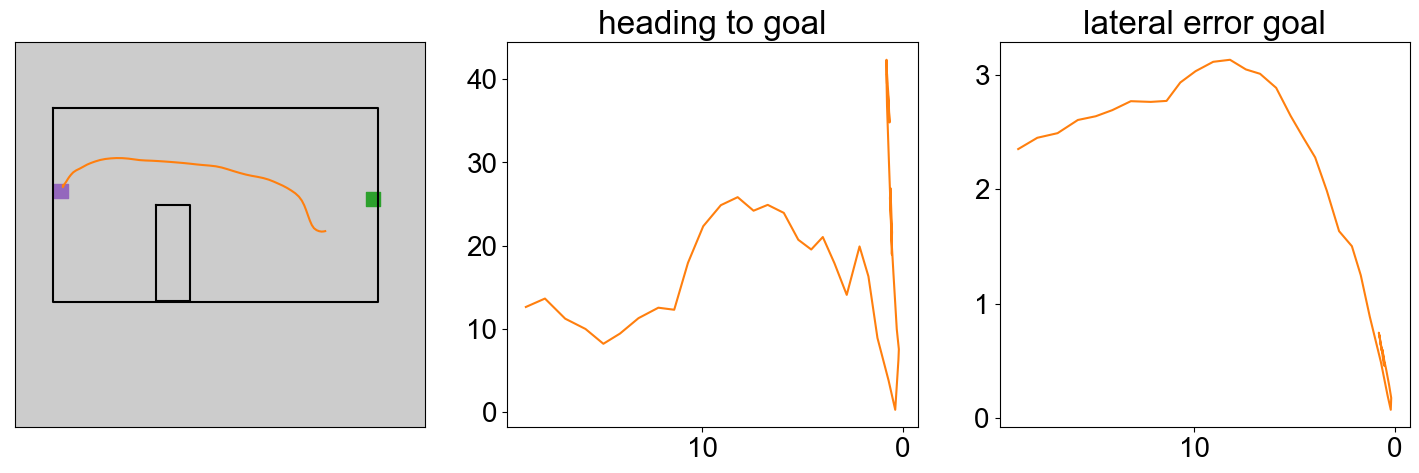

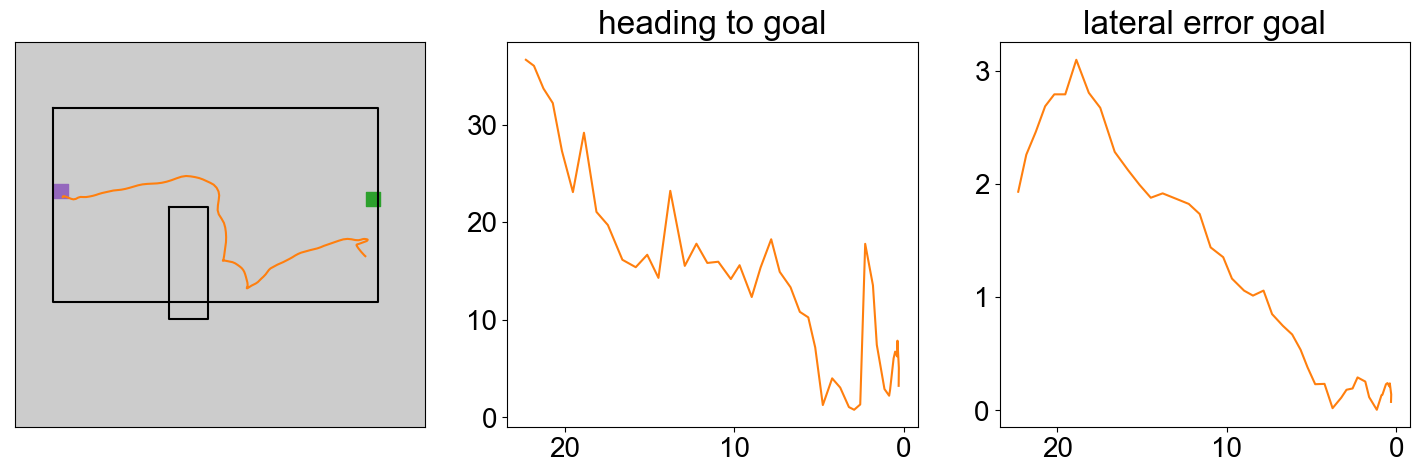

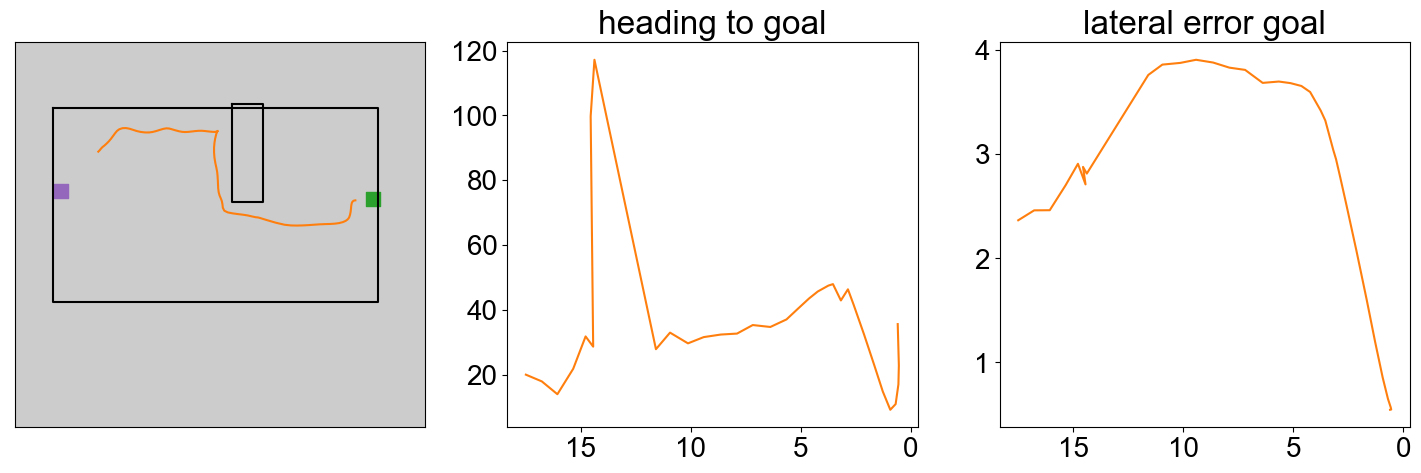

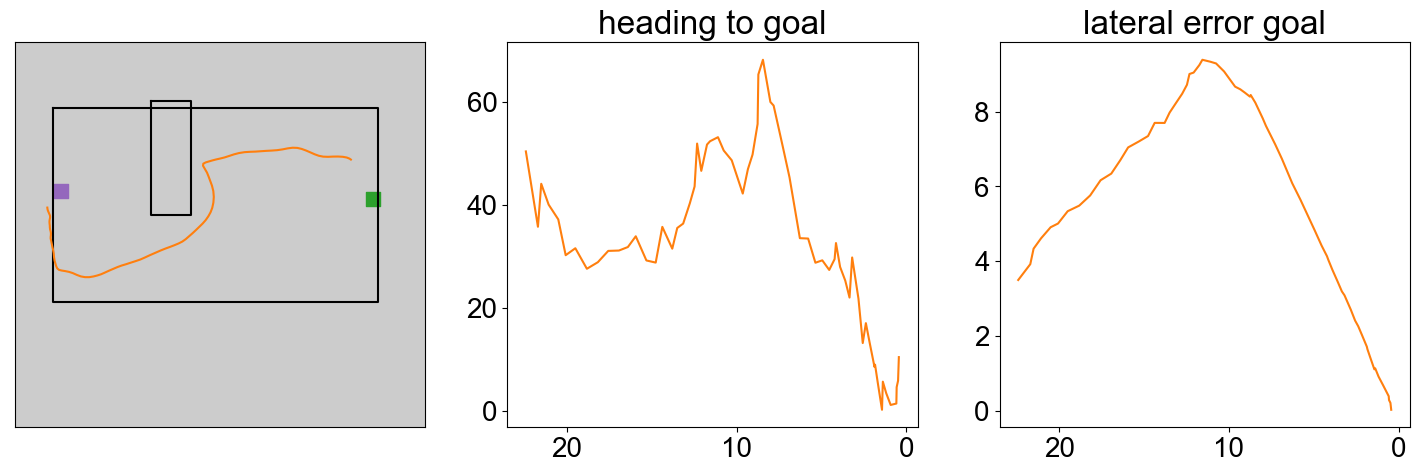

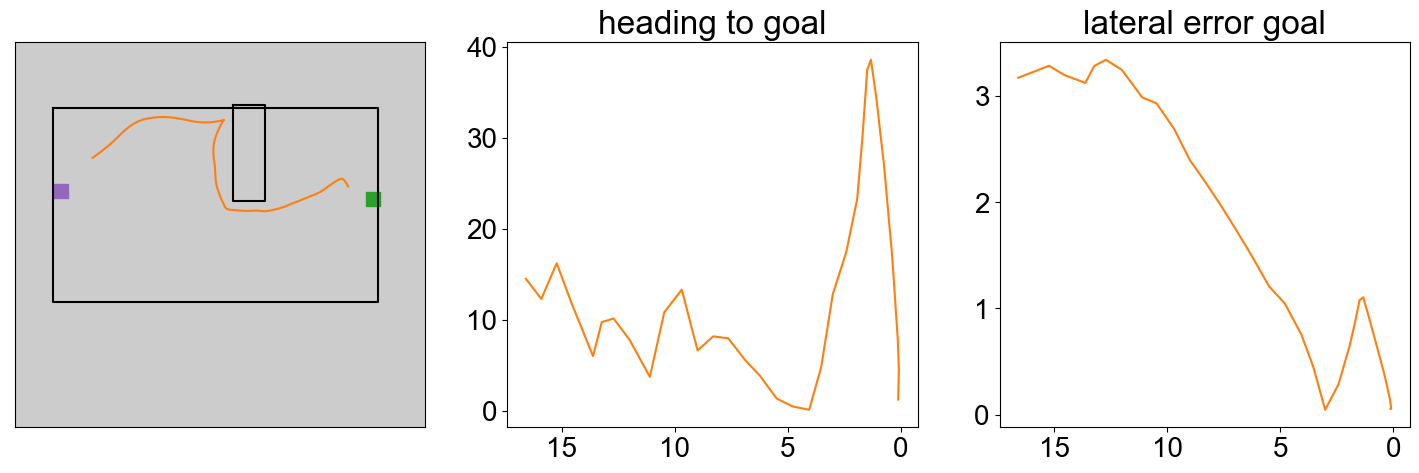

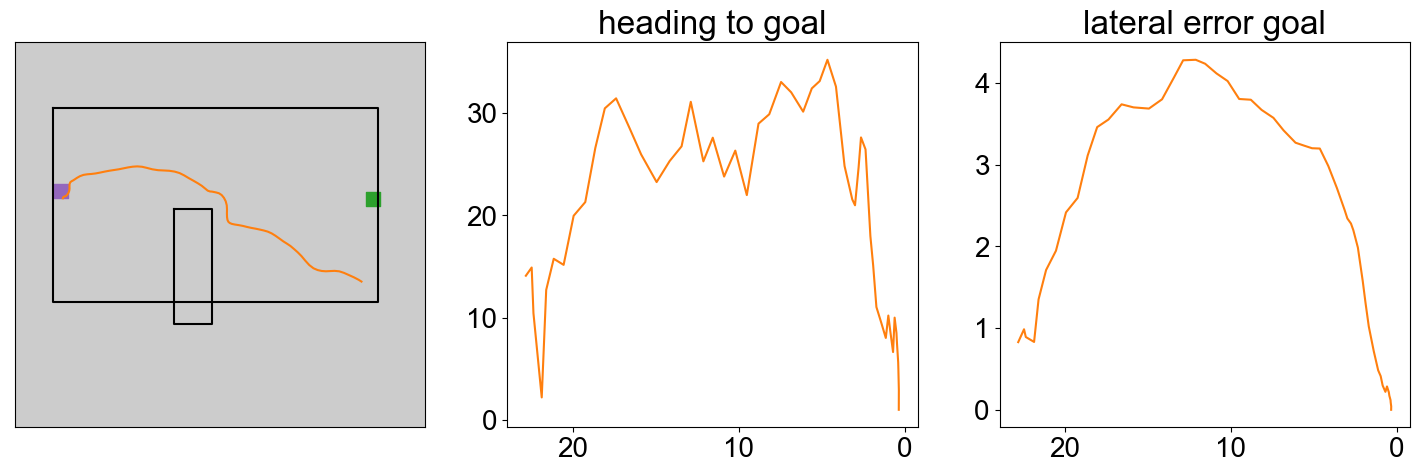

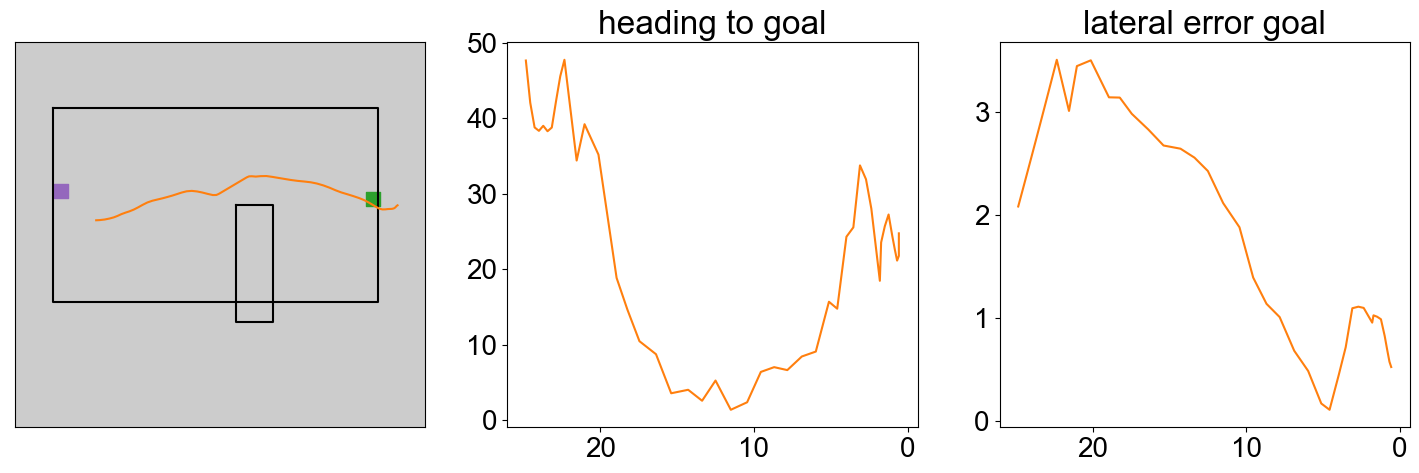

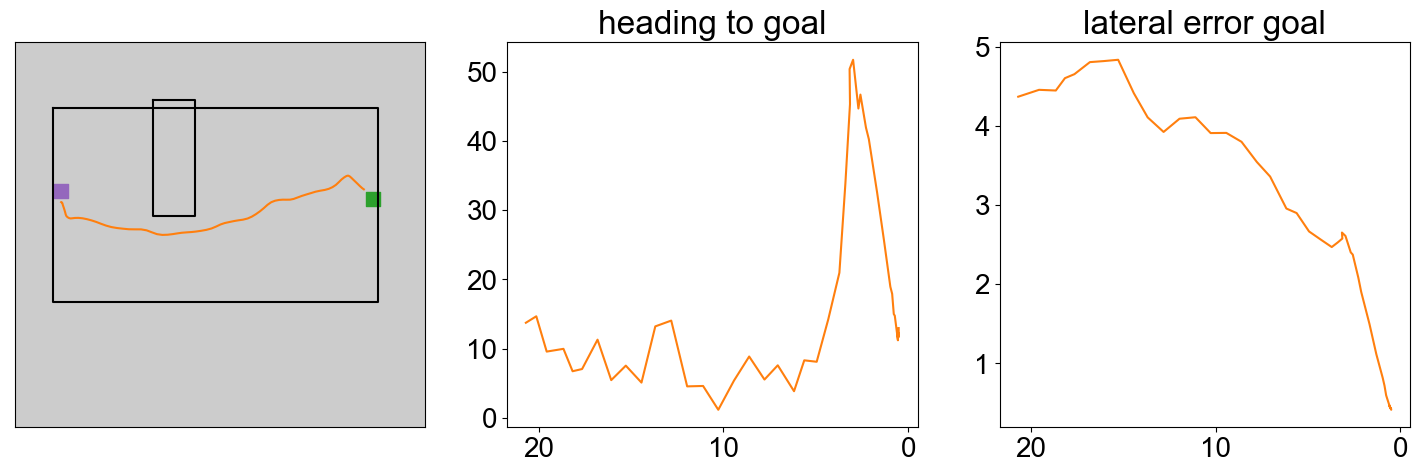

In [11]:
test = long[long.task == 'oadark'].sample(10)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
    ax[1].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('heading to goal')
    ax[2].set_title('lateral error goal')
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( (row.ts_distance_from_target_port[int(row.obstacle_ind):]),(row.ts_lateral_error_to_target_port[int(row.obstacle_ind):]),color = 'tab:orange')
    ax[1].plot( (row.ts_distance_from_target_port[int(row.obstacle_ind):]),(row.ts_angle_to_target_port[int(row.obstacle_ind):]),color = 'tab:orange')